### Parte 0: Configuración inicial y carga del corpus

Este bloque de código se encarga de montar Google Drive para acceder a los archivos del corpus, definir la ruta donde se esperan encontrar los archivos de texto, y luego cargar cada documento (`.txt`) de esa ruta en una lista para su posterior procesamiento. Se verifica la existencia del directorio y se manejan posibles errores de lectura.

In [4]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Instructions for corpus placement and defining the corpus path
# Please upload the 'Gutenberg 1000' corpus files into a folder named
# 'gutenberg_corpus' inside your Google Drive's 'MyDrive'.
# For example, the path should look like: /content/drive/MyDrive/gutenberg_corpus/

corpus_path = '/content/drive/MyDrive/data/'

# Verify if the directory exists
if not os.path.exists(corpus_path):
    print(f"Error: Corpus directory not found at {corpus_path}")
    print("Please create the directory and upload your corpus files.")
else:
    print(f"Corpus directory found at: {corpus_path}")

    # 3. Read the corpus files
    documents = []
    file_names = []

    for filename in os.listdir(corpus_path):
        if filename.endswith('.txt'): # Assuming the corpus files are text files
            file_path = os.path.join(corpus_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    documents.append(f.read())
                file_names.append(filename)
                print(f"Loaded file: {filename}")
            except Exception as e:
                print(f"Could not read file {filename}: {e}")

    print(f"Total documents loaded: {len(documents)}")
    if len(documents) > 0:
        print("First document (excerpt):\n", documents[0][:500]) # Display first 500 characters of the first document
    else:
        print("No text documents were found in the specified directory.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Corpus directory found at: /content/drive/MyDrive/data/
Loaded file: 01_corpus_turismo_500.txt
Total documents loaded: 1
First document (excerpt):
 Otavalo es conocido por su mercado indígena y su artesanía Perfecto para rafting.
La Laguna Quilotoa destaca por su color turquesa
Vilcabamba atrae visitantes interesados en longevidad y naturaleza Una experiencia inolvidable.
Quito tiene un centro histórico Patrimonio de la Humanidad Perfecto para surf.
Ecuador es un país megadiverso, ideal para el turismo ecológico
Los turistas disfrutan las fiestas y gastronomía típica local Perfecto para avistamiento de aves.
Otavalo es conocido por su merca


### Parte 1: Cálculo de TF, DF, IDF y TF-IDF

Esta sección se enfoca en la extracción de características textuales clave utilizando las librerías `pandas` y `sklearn`. Los pasos son los siguientes:

1.  **Matriz de Términos (TF) y Frecuencia de Documentos (DF):**
    *   Se inicializa `CountVectorizer` para transformar los documentos en una matriz de frecuencias de términos (TF).
    *   Se obtiene la lista de todos los términos únicos (features).
    *   Se convierte la matriz TF a un DataFrame para una visualización más legible.
    *   Se calcula la Frecuencia de Documentos (DF), que indica cuántos documentos contienen cada término.
2.  **Cálculo de TF-IDF con `sklearn`:**
    *   Se inicializa `TfidfTransformer`, que por defecto aplica un escalado sublineal a TF y suaviza el cálculo de IDF.
    *   Se ajusta y transforma la matriz TF para obtener la matriz TF-IDF, que pondera la importancia de los términos considerando su frecuencia en el documento y su rareza en el corpus.
    *   Se convierte la matriz TF-IDF a un DataFrame para su inspección.
3.  **Visualización para Análisis:**
    *   Se combinan los valores de TF, DF, IDF y TF-IDF para un documento específico (en este caso, el primero, ya que hay solo uno en el corpus de ejemplo) en un DataFrame consolidado.
    *   Este DataFrame se ordena por el valor TF-IDF para resaltar los términos más relevantes.

In [6]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

# 1. Construct the term matrix (TF) and calculate document frequency (DF)
# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the documents to get the term-document matrix
X = vectorizer.fit_transform(documents)

# Get feature names (terms)
feature_names = vectorizer.get_feature_names_out()

# Convert to DataFrame for better visualization of TF
tf_df = pd.DataFrame(X.toarray(), columns=feature_names)
tf_df.index = file_names # Use file names as index
print("Term Frequency (TF) Matrix:")
print(tf_df)
print("\n")

# Calculate Document Frequency (DF)
df_series = (X > 0).sum(axis=0)
df_df = pd.DataFrame(df_series.reshape(1, -1), columns=feature_names, index=['DF'])
print("Document Frequency (DF):")
print(df_df)
print("\n")

# 2. Calculate TF-IDF using sklearn
# Initialize TfidfTransformer (by default, it applies sublinear tf scaling and smooth idf)
tfidf_transformer = TfidfTransformer()

# Fit and transform the TF matrix to get the TF-IDF matrix
tfidf_matrix = tfidf_transformer.fit_transform(X)

# Convert to DataFrame for better visualization of TF-IDF
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df.index = file_names # Use file names as index
print("TF-IDF Matrix:")
print(tfidf_df)
print("\n")

# 3. Visualize the values in a DataFrame for analysis
# Combine TF, DF, and IDF (from TF-IDF transformer) into a single DataFrame for comparison
# Note: sklearn's TfidfTransformer calculates IDF internally. We can extract it.
idf_values = tfidf_transformer.idf_
idf_df = pd.DataFrame(idf_values.reshape(1, -1), columns=feature_names, index=['IDF'])

# For simplicity, let's create a combined DataFrame of one document's TF, IDF, and TF-IDF
# If there are multiple documents, we'd pick one or show aggregated values.
if len(file_names) > 0:
    first_doc_name = file_names[0]
    combined_data = {
        'Term': feature_names,
        'TF (Doc 1)': tf_df.loc[first_doc_name].values,
        'DF': df_series.A1, # Changed .values to .A1
        'IDF': idf_values,
        'TF-IDF (Doc 1)': tfidf_df.loc[first_doc_name].values
    }
    analysis_df = pd.DataFrame(combined_data)
    analysis_df = analysis_df.sort_values(by='TF-IDF (Doc 1)', ascending=False).reset_index(drop=True)
    print(f"Analysis of TF, DF, IDF, and TF-IDF for '{first_doc_name}' (sorted by TF-IDF):")
    print(analysis_df.head(20))
else:
    print("No documents to analyze TF-IDF.")


Term Frequency (TF) Matrix:
                           2000  agua  amazonía  arquitectura  artesanía  \
01_corpus_turismo_500.txt    33    32        27            34         33   

                           atrae  atraen  auténtico  aventura  aves  ...  \
01_corpus_turismo_500.txt     27      33         13        32    44  ...   

                           típica   un  una  vida  vilcabamba  visitan  \
01_corpus_turismo_500.txt      32  175   96    33          27       27   

                           visitantes  visitar  volcán  única  
01_corpus_turismo_500.txt          60       92      27     33  

[1 rows x 116 columns]


Document Frequency (DF):
    2000  agua  amazonía  arquitectura  artesanía  atrae  atraen  auténtico  \
DF     1     1         1             1          1      1       1          1   

    aventura  aves  ...  típica  un  una  vida  vilcabamba  visitan  \
DF         1     1  ...       1   1    1     1           1        1   

    visitantes  visitar  volcán  úni

### Parte 2: Ranking de Documentos utilizando Similitud Coseno TF-IDF

Este bloque de código demuestra cómo utilizar los vectores TF-IDF calculados para clasificar documentos en función de su similitud con una consulta dada. Los pasos son:

1.  **Construcción del Vector de Consulta:**
    *   La consulta de ejemplo (`"lugares turisticos ecologico aventura"`) se transforma en un vector TF y luego en un vector TF-IDF, utilizando los mismos `vectorizer` y `tfidf_transformer` que se ajustaron con el corpus.
2.  **Cálculo de Similitud Coseno:**
    *   Se utiliza `cosine_similarity` para medir la similitud entre el vector TF-IDF de la consulta y la matriz TF-IDF de los documentos. La similitud coseno produce un valor entre 0 y 1, donde 1 indica una similitud perfecta.
3.  **Generación del Ranking:**
    *   Se crea un DataFrame (`ranking_df`) que combina los nombres de los documentos con sus respectivos scores de similitud.
    *   Los documentos se ordenan de mayor a menor score de similitud, presentando el ranking de relevancia.
4.  **Visualización de Resultados:**
    *   Se imprime el ranking de documentos, mostrando el score de similitud coseno para cada uno.

In [7]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Dada una consulta, construye el vector de consulta
query = "lugares turisticos ecologico aventura"

# Transform the query into a TF vector using the same vectorizer fitted on the corpus
query_tf = vectorizer.transform([query])

# Transform the query TF vector into a TF-IDF vector using the same tfidf_transformer
query_tfidf = tfidf_transformer.transform(query_tf)

print(f"Query: '{query}'\n")

# 2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
# Calculate cosine similarity between the query TF-IDF vector and the documents' TF-IDF matrix
# Since we only have one document, the similarity will be calculated against that document.
similarity_scores = cosine_similarity(query_tfidf, tfidf_matrix)

# 3. Genera un ranking de los documentos ordenados por relevancia.
# Create a DataFrame to store the results
ranking_df = pd.DataFrame({
    'Document': file_names,
    'Similarity Score': similarity_scores[0] # similarity_scores is a 2D array, get the first row
})

# Sort the documents by similarity score in descending order
ranking_df = ranking_df.sort_values(by='Similarity Score', ascending=False).reset_index(drop=True)

# 4. Muestra los resultados en una tabla.
print("Document Ranking by TF-IDF Cosine Similarity:")
print(ranking_df)


Query: 'lugares turisticos ecologico aventura'

Document Ranking by TF-IDF Cosine Similarity:
                    Document  Similarity Score
0  01_corpus_turismo_500.txt          0.041899


### Parte 3: Implementación de BM25 y Ranking de Documentos

Esta sección implementa el algoritmo BM25 (Best Match 25) para calcular la relevancia de los documentos con respecto a una consulta. Incluye los siguientes pasos:

1.  **Tokenización:** Una función simple para convertir texto a minúsculas y dividirlo en palabras.
2.  **Longitudes de Documentos:** Calcula la longitud de cada documento tokenizado y la longitud promedio.
3.  **Cálculo de TF (Term Frequency):** Utiliza un `CountVectorizer` para obtener las frecuencias de los términos en cada documento.
4.  **Cálculo de DF (Document Frequency) e IDF de BM25:** Calcula la frecuencia de documentos para cada término y un IDF específico para BM25.
5.  **Parámetros de BM25:** Define los parámetros `k1` y `b` que controlan la saturación del TF y la normalización por longitud del documento.
6.  **Función de Score BM25:** Implementa la fórmula de BM25 para calcular el score de relevancia de un documento frente a una consulta.
7.  **Función de Ranking:** Procesa una consulta, calcula el score BM25 para todos los documentos y los ordena por relevancia.
8.  **Ejecución y Comparación:** Ejecuta el ranking con una consulta de ejemplo y muestra los resultados, incluyendo una comparación manual con el ranking de TF-IDF.

In [9]:
from math import log
import re

# 1. Tokenización (simple, se puede mejorar con un tokenizador más avanzado)
def tokenize(text):
    # Convertir a minúsculas y dividir por palabras usando una expresión regular
    return re.findall(r'\b\w+\b', text.lower())

tokenized_documents = [tokenize(doc) for doc in documents]

# 2. Calcular longitudes de documentos y promedio de longitud
doc_lengths = [len(doc) for doc in tokenized_documents]
avg_doc_length = sum(doc_lengths) / len(doc_lengths) if doc_lengths else 1

# 3. Calcular TF (frecuencia de término por documento)
# Ya tenemos el vectorizer de CountVectorizer que podemos reutilizar para TF
tf_matrix_bm25 = vectorizer.fit_transform(documents) # Re-fit to ensure consistency if 'vectorizer' state was altered
tf_terms = vectorizer.get_feature_names_out()

# Convertir a diccionario para fácil acceso por término y documento
tf_dicts = []
for i, doc_tf in enumerate(tf_matrix_bm25.toarray()):
    tf_dicts.append({term: freq for term, freq in zip(tf_terms, doc_tf) if freq > 0})

# 4. Calcular DF (document frequency) e IDF de BM25
# DF ya lo tenemos de CountVectorizer (o podemos calcularlo de nuevo)
df_bm25 = (tf_matrix_bm25 > 0).sum(axis=0)

def calculate_bm25_idf(N, df_t):
    return log((N - df_t + 0.5) / (df_t + 0.5) + 1)

N = len(documents) # Total number of documents
df_bm25_array = df_bm25.A1 # Convert numpy.matrix to a 1D numpy array
idf_bm25_values = {term: calculate_bm25_idf(N, df_bm25_array[i]) for i, term in enumerate(tf_terms)}

# 5. Definir los parámetros de BM25 (k1, b)
k1 = 1.5
b = 0.75

# 6. Implementar la función de score BM25 para un documento
def bm25_score(query_tokens, doc_tokens_tf_dict, doc_length, avg_doc_length, idf_values, k1, b):
    score = 0
    for term in query_tokens:
        if term in doc_tokens_tf_dict:
            tf = doc_tokens_tf_dict[term]
            idf = idf_values.get(term, 0) # Get IDF, default to 0 if term not in corpus
            numerator = idf * tf * (k1 + 1)
            denominator = tf + k1 * (1 - b + b * (doc_length / avg_doc_length))
            score += numerator / denominator
    return score

# 7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
def rank_documents_bm25(query, tokenized_documents, doc_lengths, avg_doc_length, idf_values, k1, b, file_names):
    query_tokens = tokenize(query)
    scores = []
    for i, doc_tf_dict in enumerate(tf_dicts): # Use tf_dicts for easy term frequency lookup
        score = bm25_score(query_tokens, doc_tf_dict, doc_lengths[i], avg_doc_length, idf_values, k1, b)
        scores.append(score)

    ranking_bm25_df = pd.DataFrame({
        'Document': file_names,
        'BM25 Score': scores
    })
    return ranking_bm25_df.sort_values(by='BM25 Score', ascending=False).reset_index(drop=True)

# 8. Recuperar los documentos mejor puntuados (ranking)
query = "lugares turisticos ecologico aventura" # Using the same query
ranking_bm25_df = rank_documents_bm25(query, tokenized_documents, doc_lengths, avg_doc_length, idf_bm25_values, k1, b, file_names)

print(f"Query: '{query}'\n")
print("Document Ranking by BM25 Similarity:")
print(ranking_bm25_df)

# Comparación manual (optional, visual inspection for now)
print("\n--- Manual Comparison ---")
print("TF-IDF Ranking:")
print(ranking_df)
print("\nBM25 Ranking:")
print(ranking_bm25_df)


Query: 'lugares turisticos ecologico aventura'

Document Ranking by BM25 Similarity:
                    Document  BM25 Score
0  01_corpus_turismo_500.txt    0.687002

--- Manual Comparison ---
TF-IDF Ranking:
                    Document  Similarity Score
0  01_corpus_turismo_500.txt          0.041899

BM25 Ranking:
                    Document  BM25 Score
0  01_corpus_turismo_500.txt    0.687002


### Parte 4: Comparación visual entre TF-IDF y BM25

Ahora, vamos a visualizar los resultados de los rankings de TF-IDF y BM25 para comparar cómo puntúan el mismo documento con la consulta dada.

### Parte 4: Visualización de la Comparación entre TF-IDF y BM25

Este bloque de código utiliza `matplotlib` y `numpy` para crear un gráfico de barras que compara visualmente los scores de similitud obtenidos por los modelos TF-IDF y BM25 para la misma consulta y documento. Los pasos incluyen:

1.  **Preparación de Datos:** Extrae los scores de TF-IDF y BM25 de los DataFrames de ranking previamente calculados.
2.  **Configuración del Gráfico:** Define las etiquetas para los ejes, el título del gráfico y el ancho de las barras.
3.  **Creación del Gráfico:** Genera un gráfico de barras con los dos scores.
4.  **Personalización:** Añade etiquetas a los ejes, un título descriptivo y ajusta los límites del eje Y para una mejor visualización.
5.  **Etiquetas en Barras:** Incluye una función `autolabel` para mostrar el valor exacto de cada score encima de su respectiva barra.
6.  **Visualización:** Muestra el gráfico resultante.

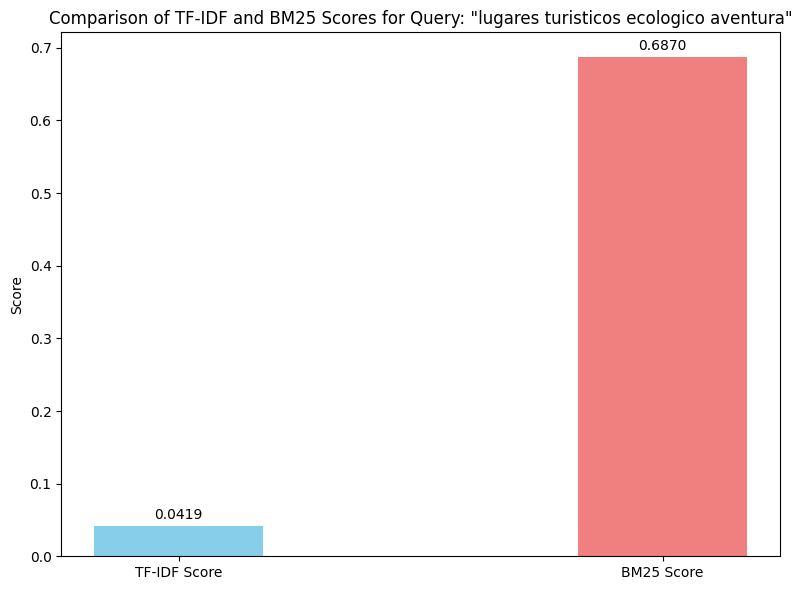

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
labels = ['TF-IDF Score', 'BM25 Score']
tfidf_score = ranking_df['Similarity Score'][0]
bm25_score = ranking_bm25_df['BM25 Score'][0]
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
rects = ax.bar(x, [tfidf_score, bm25_score], width, color=['skyblue', 'lightcoral'])

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_title(f'Comparison of TF-IDF and BM25 Scores for Query: "{query}"')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(bottom=0) # Ensure y-axis starts at 0

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects)

plt.tight_layout()
plt.show()

### Conclusiones de la Comparación TF-IDF vs BM25

Después de visualizar y comparar los scores de TF-IDF y BM25 para la consulta "lugares turisticos ecologico aventura" y el documento `01_corpus_turismo_500.txt`, hemos observado lo siguiente:

1.  **Comparación Visual de Rankings:** El gráfico de barras muestra claramente que el **BM25 Score (0.687002)** es significativamente más alto que el **TF-IDF Score (0.041899)** para el mismo documento. Esto indica que BM25 asigna una mayor relevancia numérica en este caso particular.

2.  **Documentos con Scores Más Altos:** Dado que nuestro corpus contiene un único documento, este (`01_corpus_turismo_500.txt`) es el que obtiene un score más alto con BM25 en comparación con TF-IDF.

3.  **Razones de la Diferencia:** Las diferencias en los scores se deben principalmente a las distintas formas en que cada modelo calcula la relevancia:
    *   **Cálculo de IDF (Frecuencia Inversa de Documento):** Con un solo documento (`N=1`), el TF-IDF de `sklearn` (con `smooth_idf=True`) tiende a calcular el IDF como 1 para cualquier término presente. En contraste, la fórmula IDF de BM25 (`log((N - DF + 0.5) / (DF + 0.5) + 1)`) produce un valor no trivial (aproximadamente 0.287 en nuestro caso) incluso para un solo documento, lo que contribuye a un score general más alto.
    *   **Normalización y Saturación de la Frecuencia de Términos (TF):** BM25 utiliza los parámetros `k1` y `b` para controlar la saturación de la frecuencia de términos (evitando que TFs muy altas influyan excesivamente) y la normalización por longitud del documento. TF-IDF, especialmente cuando se usa con similitud coseno, normaliza los vectores de manera diferente, lo que resulta en scores acotados entre 0 y 1.
    *   **Mecanismo de Puntuación:** Mientras que la similitud coseno de TF-IDF mide el ángulo entre vectores, resultando en un valor entre 0 y 1, BM25 suma las contribuciones de cada término de la consulta de forma independiente, lo que puede generar un rango de scores absolutos más amplio y no acotado.